# Part 1 — Sanity check & visual verification
using ε = 0.01, M∞ = 0.1, domain (−4, 4) × (0, 4), grid 161 × 81.

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import utils
importlib.reload(utils)

from utils import solve_potential, Usurf_on_y0, compute_uv, dYb_dx

In [ ]:
# test run with sor
eps, M = 0.01, 0.1
q, s, r = 4.0, 4.0, 4.0
Nx, Ny = 161, 81

phi, x, y, info = solve_potential(
    eps=eps, M=M, q=q, s=s, r=r, Nx=Nx, Ny=Ny,
    method="sor", omega=1.7,
    tol_res=1e-5, tol_upd=1e-5,
    max_iter=30000, check_every=200,
    verbose=True,
)
print(f"Converged: {info['converged']}  |  iters: {info['iters']}  |  time: {info['seconds']:.2f}s")

[sor(w=1.700)] it=      1  res=3.518e-01  rel=1.319e+00  upd=4.730e-04 ρ≈nan  t=0.00s
[sor(w=1.700)] it=    200  res=4.124e-03  rel=1.547e-02  upd=6.469e-03 ρ≈1.0132  t=0.05s
[sor(w=1.700)] it=    400  res=1.800e-03  rel=6.750e-03  upd=9.148e-04 ρ≈0.9903  t=0.09s
[sor(w=1.700)] it=    600  res=1.388e-03  rel=5.204e-03  upd=6.824e-04 ρ≈0.9985  t=0.12s
[sor(w=1.700)] it=    800  res=1.060e-03  rel=3.974e-03  upd=5.191e-04 ρ≈0.9986  t=0.16s
[sor(w=1.700)] it=   1000  res=8.332e-04  rel=3.125e-03  upd=4.020e-04 ρ≈0.9987  t=0.19s
[sor(w=1.700)] it=   1200  res=6.691e-04  rel=2.509e-03  upd=3.196e-04 ρ≈0.9989  t=0.22s
[sor(w=1.700)] it=   1400  res=5.437e-04  rel=2.039e-03  upd=2.582e-04 ρ≈0.9989  t=0.26s
[sor(w=1.700)] it=   1600  res=4.443e-04  rel=1.666e-03  upd=2.105e-04 ρ≈0.9990  t=0.29s
[sor(w=1.700)] it=   1800  res=3.641e-04  rel=1.366e-03  upd=1.723e-04 ρ≈0.9990  t=0.32s
[sor(w=1.700)] it=   2000  res=2.988e-04  rel=1.121e-03  upd=1.413e-04 ρ≈0.9990  t=0.36s
[sor(w=1.700)] it=   220

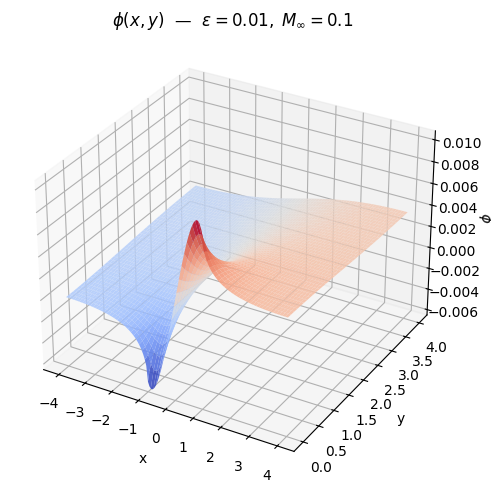

In [ ]:
# 3-D surface of φ 
from mpl_toolkits.mplot3d import Axes3D
X, Y = np.meshgrid(x, y, indexing="ij")
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, phi, rstride=2, cstride=2, cmap="coolwarm", linewidth=0, alpha=0.9)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel(r"$\phi$")
ax.set_title(r"$\phi(x,y)$  —  $\varepsilon=0.01,\; M_\infty=0.1$")
plt.tight_layout(); plt.show()

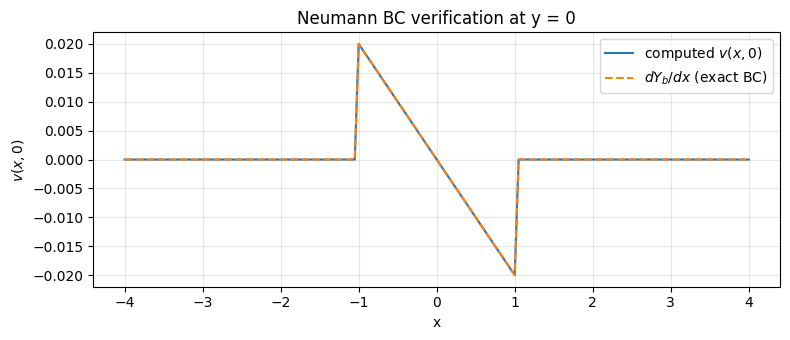

In [ ]:
# verify Neumann BC at y = 0
u, v = compute_uv(phi, info["dx"], info["dy"])
g_exact = dYb_dx(x, eps)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(x, v[:, 0], label=r"computed $v(x,0)$")
ax.plot(x, g_exact, "--", label=r"$dY_b/dx$ (exact BC)")
ax.set_xlabel("x"); ax.set_ylabel(r"$v(x,0)$")
ax.set_title("Neumann BC verification at y = 0")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()